# SmolLM2 PDelta3-GDN2-CLVR + Local32 — Sequential Optimization

This Colab ports the strongest Tiny-LLM recurrent candidate to **SmolLM2-135M** and replaces attention **one layer at a time**.

Key changes versus the earlier Memory Fusion sequential run:

- **PDelta3 / GDN2** recurrent global state, using the Tiny-LLM winner as the starting point.
- **True one-hop CLVR on SmolLM2**: layer `i>0` routes the previous accepted layer's V representation. Layer 0 uses current-V routing as the one-layer proxy.
- **Bounded exact local window (`W=32`)** to protect short-range syntax while the recurrent state handles longer-range information.
- **Logit-first rescue rounds**: later rounds increase teacher KL / LM CE emphasis when representation similarity is already good but ΔNLL is still too high.
- **Best-quality rollback**: after every acceptance check the best ΔNLL checkpoint is remembered; an unfinished round resumes from the best checkpoint, not blindly from the last optimizer step.
- **Warm-start next layer** from the previous accepted recurrent core.
- Strict layer acceptance remains enabled by default.

The first run targets 6 layers so you can see the trend before committing to all 30. Increase `TARGET_LAYERS` later and rerun with `RESUME=True`.


In [1]:
import os, sys, pathlib, subprocess, json, time
import torch

subprocess.run(["nvidia-smi"], check=False)

REPO_DIR = pathlib.Path("/content/TinyCeNN-LM")
if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/vtavakkoli/TinyCeNN-LM.git", str(REPO_DIR)],
        check=True,
    )
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR),
        "transformers==4.57.6", "datasets>=3,<5",
        "huggingface_hub>=0.34,<2", "pandas", "matplotlib", "safetensors",
    ],
    check=True,
)

for p in (REPO_DIR / "src", REPO_DIR, REPO_DIR / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import tinycenn_lm
print("python:", sys.executable)
print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())
print("tinycenn_lm:", tinycenn_lm.__file__)


python: /usr/bin/python3
torch: 2.11.0+cu128 cuda: True
tinycenn_lm: /content/TinyCeNN-LM/src/tinycenn_lm/__init__.py


In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

DRIVE_ROOT = pathlib.Path("/content/drive/MyDrive/TinyCeNN-LM")
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
print("persistent root:", DRIVE_ROOT)


Mounted at /content/drive
persistent root: /content/drive/MyDrive/TinyCeNN-LM


## Experiment settings

The acceptance gates are deliberately not relaxed. The experiment should only advance to the next layer when the replacement preserves held-out LM quality closely enough.


In [3]:
BASE_MODEL = "HuggingFaceTB/SmolLM2-135M"

# Architecture selected from the Tiny-LLM experiment, adapted to multi-layer SmolLM2.
FEATURE_DIM = 96
LOCAL_WINDOW = 32
CHUNK_SIZE = 32
CONV_KERNEL = 4
STATE_DTYPE = "fp16"
LOCAL_GATE_INIT = 0.72
WARM_START_PREVIOUS_CORE = True

# Start with a pilot prefix. Change to 30 later to continue the full conversion.
TARGET_LAYERS = 6

# Training/evaluation.
CONTEXT_LENGTH = 256
PROBE_CONTEXT = 256
PROBE_BLOCKS = 8
SEED = 2026
MIN_LAYER_STEPS = 75
MAX_LAYER_STEPS = 300
CHECK_EVERY = 25
LAYER_LR = 4e-4
QKV_LR_SCALE = 0.20
TRAIN_QKV = True
TEMPERATURE = 1.5

# Round 1: balanced representation + logit learning.
FUNCTIONAL_WEIGHT = 0.25
KL_WEIGHT = 1.00
CE_WEIGHT = 0.10
COSINE_WEIGHT = 0.20
LOCAL_GATE_PENALTY = 0.002

# Rescue rounds: stronger logit/NLL optimization.
RESCUE_LR_SCALE = 0.45
RESCUE_FUNCTIONAL_WEIGHT = 0.10
RESCUE_KL_WEIGHT = 1.50
RESCUE_CE_WEIGHT = 0.18

# Strict scientific acceptance.
ACCEPT_NMSE = 0.15
ACCEPT_COSINE = 0.94
ACCEPT_INCREMENTAL_DELTA_NLL = 0.015
ACCEPT_CUMULATIVE_DELTA_NLL = 0.05
STRICT_ACCEPTANCE = True

RESUME = True
MAX_RUNTIME_MINUTES = 240
MAX_ROUNDS_PER_RUN = 3

OUTPUT_DIR = DRIVE_ROOT / (
    f"smollm2-pdelta3-gdn2-clvr-local{LOCAL_WINDOW}-f{FEATURE_DIM}"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("output:", OUTPUT_DIR)
print("pilot target layers:", TARGET_LAYERS)


output: /content/drive/MyDrive/TinyCeNN-LM/smollm2-pdelta3-gdn2-clvr-local32-f96
pilot target layers: 6


## Run / resume sequential replacement

Each Colab run attempts only a few rounds on the **current layer**. If that layer does not pass, the process exits successfully with `current_layer_needs_more_training`. Rerun this cell to continue from the best saved checkpoint.

Once a layer passes, it is frozen as part of the accepted prefix and the trainer moves to the next Transformer layer.


In [4]:
import signal

cmd = [
    sys.executable, "-u",
    str(REPO_DIR / "scripts" / "run_smollm2_pdelta3_clvr_sequential_colab.py"),
    "--base-model", BASE_MODEL,
    "--output-dir", str(OUTPUT_DIR),
    "--feature-dim", str(FEATURE_DIM),
    "--local-window", str(LOCAL_WINDOW),
    "--chunk-size", str(CHUNK_SIZE),
    "--conv-kernel", str(CONV_KERNEL),
    "--state-dtype", STATE_DTYPE,
    "--local-gate-init", str(LOCAL_GATE_INIT),
    "--target-layers", str(TARGET_LAYERS),
    "--context-length", str(CONTEXT_LENGTH),
    "--probe-context", str(PROBE_CONTEXT),
    "--probe-blocks", str(PROBE_BLOCKS),
    "--seed", str(SEED),
    "--min-layer-steps", str(MIN_LAYER_STEPS),
    "--max-layer-steps", str(MAX_LAYER_STEPS),
    "--check-every", str(CHECK_EVERY),
    "--layer-lr", str(LAYER_LR),
    "--qkv-lr-scale", str(QKV_LR_SCALE),
    "--temperature", str(TEMPERATURE),
    "--functional-weight", str(FUNCTIONAL_WEIGHT),
    "--kl-weight", str(KL_WEIGHT),
    "--ce-weight", str(CE_WEIGHT),
    "--cosine-weight", str(COSINE_WEIGHT),
    "--local-gate-penalty", str(LOCAL_GATE_PENALTY),
    "--rescue-lr-scale", str(RESCUE_LR_SCALE),
    "--rescue-functional-weight", str(RESCUE_FUNCTIONAL_WEIGHT),
    "--rescue-kl-weight", str(RESCUE_KL_WEIGHT),
    "--rescue-ce-weight", str(RESCUE_CE_WEIGHT),
    "--accept-nmse", str(ACCEPT_NMSE),
    "--accept-cosine", str(ACCEPT_COSINE),
    "--accept-incremental-delta-nll", str(ACCEPT_INCREMENTAL_DELTA_NLL),
    "--accept-cumulative-delta-nll", str(ACCEPT_CUMULATIVE_DELTA_NLL),
    "--max-runtime-minutes", str(MAX_RUNTIME_MINUTES),
]

cmd.append("--warm-start-previous-core" if WARM_START_PREVIOUS_CORE else "--no-warm-start-previous-core")
cmd.append("--train-qkv" if TRAIN_QKV else "--no-train-qkv")
cmd.append("--strict-acceptance" if STRICT_ACCEPTANCE else "--no-strict-acceptance")
cmd.append("--resume" if RESUME else "--no-resume")

log_path = OUTPUT_DIR / "last_colab_run.log"
print(" ".join(cmd))
print("Log:", log_path)

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"
env["SEQUENTIAL_MAX_ROUNDS_PER_RUN"] = str(MAX_ROUNDS_PER_RUN)

interrupted = False
with log_path.open("w", encoding="utf-8") as log:
    p = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )
    assert p.stdout is not None
    try:
        for line in p.stdout:
            print(line, end="")
            log.write(line)
            log.flush()
        rc = p.wait()
    except KeyboardInterrupt:
        interrupted = True
        print("\nInterrupt requested. Asking child trainer to stop cleanly...")
        p.send_signal(signal.SIGINT)
        try:
            rc = p.wait(timeout=30)
        except subprocess.TimeoutExpired:
            p.terminate()
            rc = p.wait()
        print("Saved Drive checkpoints remain usable.")

print("Process return code:", rc)

if rc != 0 and not interrupted:
    raise RuntimeError(f"Trainer failed with return code {rc}. See {log_path}.")


/usr/bin/python3 -u /content/TinyCeNN-LM/scripts/run_smollm2_pdelta3_clvr_sequential_colab.py --base-model HuggingFaceTB/SmolLM2-135M --output-dir /content/drive/MyDrive/TinyCeNN-LM/smollm2-pdelta3-gdn2-clvr-local32-f96 --feature-dim 96 --local-window 32 --chunk-size 32 --conv-kernel 4 --state-dtype fp16 --local-gate-init 0.72 --target-layers 6 --context-length 256 --probe-context 256 --probe-blocks 8 --seed 2026 --min-layer-steps 75 --max-layer-steps 300 --check-every 25 --layer-lr 0.0004 --qkv-lr-scale 0.2 --temperature 1.5 --functional-weight 0.25 --kl-weight 1.0 --ce-weight 0.1 --cosine-weight 0.2 --local-gate-penalty 0.002 --rescue-lr-scale 0.45 --rescue-functional-weight 0.1 --rescue-kl-weight 1.5 --rescue-ce-weight 0.18 --accept-nmse 0.15 --accept-cosine 0.94 --accept-incremental-delta-nll 0.015 --accept-cumulative-delta-nll 0.05 --max-runtime-minutes 240 --warm-start-previous-core --train-qkv --strict-acceptance --resume
Log: /content/drive/MyDrive/TinyCeNN-LM/smollm2-pdelta3-g

## Current status and best checkpoint


In [5]:
status_files = [
    OUTPUT_DIR / "sequential_run_status.json",
    OUTPUT_DIR / "sequential_progress.json",
    OUTPUT_DIR / "sequential_in_progress.json",
]
for path in status_files:
    if path.exists():
        print("\n###", path.name)
        data = json.loads(path.read_text(encoding="utf-8"))
        print(json.dumps(data, indent=2)[:18000])

progress_path = OUTPUT_DIR / "sequential_progress.json"
in_progress_path = OUTPUT_DIR / "sequential_in_progress.json"

accepted = []
if progress_path.exists():
    accepted = json.loads(progress_path.read_text())["accepted_layers"]
print("\nAccepted prefix:", accepted)

if in_progress_path.exists():
    current = json.loads(in_progress_path.read_text())
    print(
        "Current layer:", current["current_layer"],
        "rounds:", current["rounds_completed"],
    )



### sequential_run_status.json
{
  "status": "current_layer_needs_more_training",
  "architecture": "PDelta3-GDN2-CLVR+LocalW",
  "accepted_layers": [
    0,
    1,
    2
  ],
  "current_layer": 3,
  "rounds_completed": 3,
  "last_report": {
    "layer": 3,
    "nmse": 0.2264630552381277,
    "cosine": 0.8949152529239655,
    "probe_nll": 2.8184992969036102,
    "incremental_delta_nll": 0.0027824342250823975,
    "cumulative_delta_nll": 0.014873117208480835,
    "local_gate_mean": 0.44122464209795,
    "step": 300,
    "round": 3,
    "accepted": false
  },
  "message": "No next Transformer layer was replaced. Rerun to continue from the best saved quality checkpoint."
}

### sequential_progress.json
{
  "format_version": 1,
  "architecture": "smollm2-pdelta3-gdn2-clvr-local-sequential",
  "accepted_layers": [
    0,
    1,
    2
  ],
  "config": {
    "feature_dim": 96,
    "local_window": 32,
    "chunk_size": 32,
    "conv_kernel": 4,
    "state_dtype": "fp16",
    "variant": "conv4

## Quality trend

The most important curve is **incremental ΔNLL**. It must fall below `0.015` before the current replacement is accepted. The cumulative gate prevents many individually small errors from accumulating into a degraded full model.


,layer,nmse,cosine,probe_nll,incremental_delta_nll,cumulative_delta_nll,local_gate_mean,step,round,accepted
0,0,0.006911,0.997432,2.806019,0.002393,0.002393,0.749045,75,1,True
1,1,0.010800,0.995983,2.815738,0.009719,0.012112,0.765899,75,1,True
2,2,0.085569,0.958695,2.815717,-0.000021,0.012091,0.765531,75,1,True
3,3,0.275014,0.869178,2.822609,0.006892,0.018983,0.472024,275,1,False
4,3,0.251297,0.881262,2.819875,0.004158,0.016249,0.448561,250,2,False
5,3,0.226463,0.894915,2.818499,0.002782,0.014873,0.441225,300,3,False


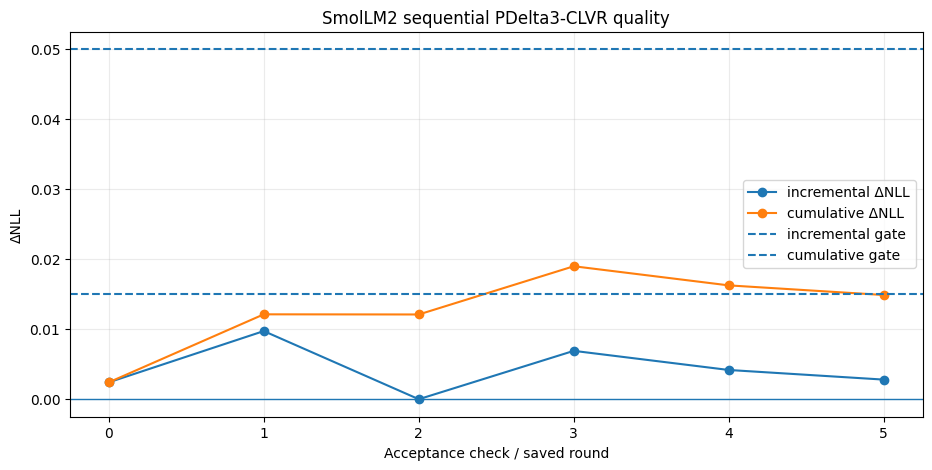

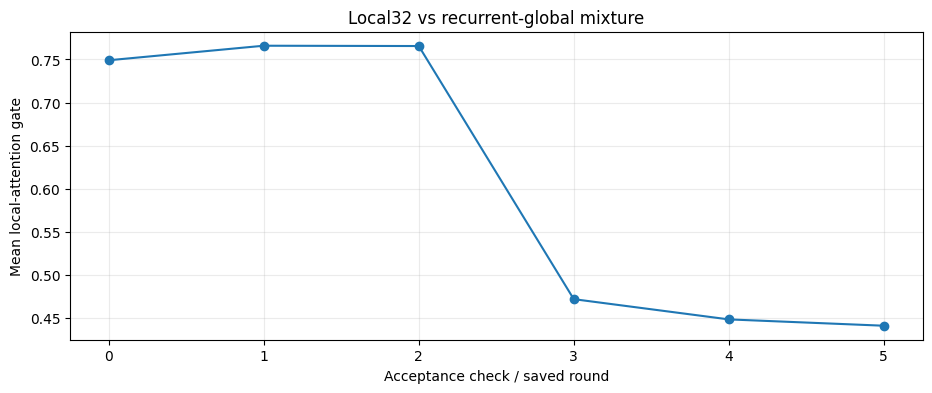

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

records = []
source = None
if in_progress_path.exists():
    source = json.loads(in_progress_path.read_text())
elif progress_path.exists():
    source = json.loads(progress_path.read_text())

if source:
    for r in source.get("layer_reports", []):
        records.append(r)

if not records:
    print("No layer reports yet. Run the trainer first.")
else:
    df = pd.DataFrame(records)
    display(df.tail(30))

    x = range(len(df))
    plt.figure(figsize=(11, 5))
    plt.plot(x, df["incremental_delta_nll"], marker="o", label="incremental ΔNLL")
    plt.plot(x, df["cumulative_delta_nll"], marker="o", label="cumulative ΔNLL")
    plt.axhline(ACCEPT_INCREMENTAL_DELTA_NLL, linestyle="--", label="incremental gate")
    plt.axhline(ACCEPT_CUMULATIVE_DELTA_NLL, linestyle="--", label="cumulative gate")
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Acceptance check / saved round")
    plt.ylabel("ΔNLL")
    plt.title("SmolLM2 sequential PDelta3-CLVR quality")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    if "local_gate_mean" in df.columns:
        plt.figure(figsize=(11, 4))
        plt.plot(x, df["local_gate_mean"], marker="o")
        plt.xlabel("Acceptance check / saved round")
        plt.ylabel("Mean local-attention gate")
        plt.title("Local32 vs recurrent-global mixture")
        plt.grid(alpha=0.25)
        plt.show()


## Prompt smoke test of the accepted prefix

This cell deliberately loads only `sequential_progress.pt`, so a partially trained current layer is excluded.


In [7]:
import importlib.util
from transformers import AutoModelForCausalLM, AutoTokenizer

progress_pt = OUTPUT_DIR / "sequential_progress.pt"
if not progress_pt.exists():
    print("No formally accepted layer yet; prompt test skipped.")
else:
    module_path = REPO_DIR / "scripts" / "train_smollm2_pdelta3_clvr_sequential.py"
    spec = importlib.util.spec_from_file_location("smol_pdelta3_seq", module_path)
    smolopt = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = smolopt
    assert spec.loader is not None
    spec.loader.exec_module(smolopt)

    payload = torch.load(progress_pt, map_location="cpu", weights_only=False)
    accepted_layers = [int(x) for x in payload["accepted_layers"]]
    cfg = smolopt.PDelta3CLVRConfig.from_dict(payload["config"])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dtype = (
        torch.bfloat16
        if device.type == "cuda" and torch.cuda.is_bf16_supported()
        else torch.float16 if device.type == "cuda" else torch.float32
    )

    tok = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token

    baseline = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=dtype).to(device).eval()
    baseline.config.use_cache = False

    hybrid = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=dtype).to(device).eval()
    hybrid.config.use_cache = False
    for idx in accepted_layers:
        smolopt.install_replacement(
            hybrid, idx, cfg, warm_start_previous_core=False
        )
    incompatible = hybrid.load_state_dict(payload["attention_state"], strict=False)
    unexpected = [
        k for k in incompatible.unexpected_keys
        if any(k.startswith(f"model.layers.{i}.self_attn.") for i in accepted_layers)
    ]
    if unexpected:
        raise RuntimeError(f"Unexpected accepted-state keys: {unexpected[:10]}")

    prompts = [
        "The future of small language models is",
        "Artificial intelligence can help scientists by",
        "A good software architecture should",
        "The capital of Austria is",
        "Once upon a time, a small robot",
    ]

    @torch.inference_mode()
    def complete(model, prompt, max_new_tokens=36):
        inputs = tok(prompt, return_tensors="pt").to(device)
        ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=False,
            pad_token_id=tok.eos_token_id,
            eos_token_id=tok.eos_token_id,
        )
        return tok.decode(ids[0], skip_special_tokens=True)

    print("Accepted PDelta3-CLVR layers:", accepted_layers)
    for prompt in prompts:
        print("\n" + "=" * 100)
        print("PROMPT:", prompt)
        print("\nBASELINE:")
        print(complete(baseline, prompt))
        print("\nPDELTA3-CLVR ACCEPTED PREFIX:")
        print(complete(hybrid, prompt))


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Accepted PDelta3-CLVR layers: [0, 1, 2]

PROMPT: The future of small language models is

BASELINE:
The future of small language models is to be determined by the needs of the users.

The future of small language models is to be determined by the needs of the users.

The future of small language

PDELTA3-CLVR ACCEPTED PREFIX:
The future of small language models is uncertain.

The future of small language models is uncertain.

The future of small language models is uncertain.

The future of small language models is uncertain.


PROMPT: Artificial intelligence can help scientists by

BASELINE:
Artificial intelligence can help scientists by identifying and understanding the underlying causes of disease.

The ability to predict disease is a key component of the field of medicine. The ability to predict disease is also important for the

PDELTA3-CLVR ACCEPTED PREFIX:
Artificial intelligence can help scientists by providing a more accurate and detailed picture of the world around us.

The abi